**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import Any, NamedTuple
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_shadowgram

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.utils import savefig_to

**Notebook's General Variables**

In [2]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_newSG_smoothing'
SAVE_THINGS: bool = False

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = False

**Mask and Data Specifics**

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_upx2upy1"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = (
    True if DATASET == 'reconstructed'
    else False
)

**Analysis Methods**

In [4]:
class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float


def get_candidates(
    log: Log,
    thresh: int | float,
) -> tuple[Candidate, ...]:
    """
    Extracts the candidates from the IROS log with a
    significance lower than the input threshold.
    """
    _upto: int = np.argwhere(
        np.array(log.log['snr']) < thresh
    )[0, 0]

    candidates: tuple[Candidate, ...] = tuple(
        Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
            log.log['shift_x'][:_upto],
            log.log['shift_y'][:_upto],
            log.log['fluence'][:_upto],
            log.log['snr'][:_upto],
        )
    )
    print(
        f"Number of candidates with SNR > {thresh}: {len(candidates)}\n"
        f"Last: {log.log['ID'][_upto - 1]} (snr = {log.log['snr'][_upto - 1]:.2f})\n"
        f"Following: {log.log['ID'][_upto]} (snr = {log.log['snr'][_upto]:.2f})\n"
    )
    return candidates


def retrieve_detector(
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Generates detector image from retrieved candidates."""
    detector = np.zeros(camera.shape_detector)
    for (sx, sy, f, _) in candidates:
        sg = model_shadowgram(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            vignetting=vignetting,
            psfy=psfy,
        )
        detector += (f * sg)
    return detector


def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    sources, thetas_x, thetas_y = [], [], []
    for sourceID in log.log['ID']:
        if sourceID in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)][0]    # NOTE!!!
            sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
            thetax, thetay = map(lambda x: shift2angle(camera, x), (sx, sy))
            sources.append(sourceID)
            thetas_x.append(thetax)
            thetas_y.append(thetay)
        else:
            print(f'Source {sourceID.upper()} not in catalogue...')
            sources.append(sourceID)
            thetas_x.append(np.nan)
            thetas_y.append(np.nan)
        
    df = pd.DataFrame(
        {'ID': sources, 'THETAX': thetas_x, 'THETAY': thetas_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    theta_x, theta_y = map(
        np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - theta_x),
        60 * np.abs(np.array(log.log['angle_y']) - theta_y),
    )
    return res_x, res_y

In [5]:
def config_snrlim(
    bins: NDArray,
    start: int | float | None,
    stop: int | float | None,
) -> tuple[slice, slice]:
    """
    Configures significance histograms values to show.

    Args:
        bins (NDArray): Bins array values.
        start (int | float): Inf significance limit.
        stop (int | float): Sup significance limit.
    
    Returns:
        output (tuple[slice, slice]):
            - slice obj for bins values
            - slice obj for histogram values
    """
    i_min = (
        bisect_right(bins, start) - 1 if start is not None else None
    )
    i_max = (
        bisect_left(bins, stop) if stop is not None else None
    )
    slice_bins = slice(i_min, i_max)
    slice_hist = slice(i_min, i_max - 1 if i_max else None)
    return slice_bins, slice_hist


def data_DF(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    def dict2df(data: dict[str, dict[str, Any]]) -> pd.DataFrame:
        """
        Converts input data dict in Dataframe.
        """
        df = pd.DataFrame({
            (cam, param): values
            for cam, cam_data in data.items() 
            for param, values in cam_data.items()
        })
        return df
    
    pxdim_y, pxdim_x = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    dtheta_y, dtheta_x = map(
        lambda x: np.rad2deg(np.arctan(x / camera.specs.mask_detector_distance)) * 60,
        (pxdim_y, pxdim_x),
    )    
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log=log,
        catalogue=catalogue,
        sdl=sdl,
        camera=camera,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'SNR': log.log['snr'],
            'SHIFT_X [mm]': log.log['shift_x'],
            'SHIFT_Y [mm]': log.log['shift_y'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
        }
    }
    print(
        f"Pixel angular resolution at upscaling (x, y): {camera.upscale_f.x}, {camera.upscale_f.y}\n"
        f"  - fine direction: {dtheta_x:.4f} arcmin\n"
        f"  - coarse direction: {dtheta_y:.4f} arcmin\n"
    )
    return dict2df(dmap)


def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)


def Gaussian(x: NDArray, x0: float = 0.0, sigma: float = 1.0) -> NDArray:
    """Returns a 1D Gaussian distribution centered around `x0` and with std `sigma`."""
    return (
        1.0 / np.sqrt(2 * np.pi * np.square(sigma)) * np.exp(-np.square(x - x0) / (2 * np.square(sigma)))
    )

**Load Mask and Data**

In [6]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
ASPECT: float = (wfm.specs.mask_deltay / UPS_Y) / (wfm.specs.mask_deltax / UPS_X)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [7]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
#res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [8]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
true_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID}.fits")
#res_sky_camB, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [ ]:
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


**Analysis for LEM-X Camera A**

In [10]:
assert ANALYSIS_CAM1A

In [11]:
# sources data + angular coords residues plot
data_DF(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

Source LEMX-CAM1AS1 not in catalogue...
Pixel angular resolution at upscaling (x, y): 2, 1
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin



CAM1A                                                         \
                ID         SNR SHIFT_X [mm] SHIFT_Y [mm] DthetaX [arcmin]   
0            scox1  718.749706    43.910887    78.044285         0.024011   
1            gx5-1   70.508719    13.534316   -12.431045         0.086909   
2          gx349+2   49.091788   -28.175043    28.737021         0.093143   
3           gx17+2   39.803828    53.625000   -27.500000         0.626402   
4            gx9+1   38.683544    29.856588   -13.329604         0.082975   
5          gx340+0   31.368753   -64.628033    39.239861         0.120519   
6      groj1655-40   27.629850   -41.789720    36.409350         0.107131   
7           gx13+1   23.767172    41.892025   -24.795763         0.159259   
8        x1820-303   23.606826    -6.285518   -28.801616         0.288474   
9            gx3+1   20.187057     8.426808    -2.640448         0.100095   
10           cirx1   28.238409  -134.710744    82.405372         0.054614   
11           gx9+9   15.786954    42.983145    11.506533         0.182933   
12       x1735-444   12.808714   -56.389361     6.500000         0.083391   
13       x1705-440   12.102994   -56.439860    25.270706         0.192796   
14     grs1915+105   16.721592   174.999104  -108.775431         0.103521   
15         gx354-0    6.202994   -17.625000    10.908333         1.263879   
16  igrj17098-3626    5.244085   -27.875000    25.797118         2.751175   
17    lemx-cam1aS1    5.052764   -31.946288   -24.000000              NaN   
18       x1636-536    5.699422   -98.614048    39.000000         0.167379   
19       x1624-490    5.210701   -81.685350    49.500000         0.566473   

                     
   DthetaY [arcmin]  
0          0.022553  
1          1.351442  
2          1.464105  
3          5.079425  
4          0.755001  
5          2.265733  
6          5.620446  
7          5.412304  
8          8.009776  
9         13.312064  
10         0.404232  
11         8.719137  
12        36.341051  
13        16.441951  
14         8.482009  
15        14.001131  
16         1.275602  
17              NaN  
18        21.545558  
19        13.856071

In [12]:
SMOOTHING_THRESHOLD: int | float = 15.0

candidates: tuple[Candidate, ...] = get_candidates(log_camA, SMOOTHING_THRESHOLD)

Number of candidates with SNR > 15.0: 12
Last: gx9+9 (snr = 15.79)
Following: x1735-444 (snr = 12.81)



## USING BULK MASK with 1.5 mm cover ##


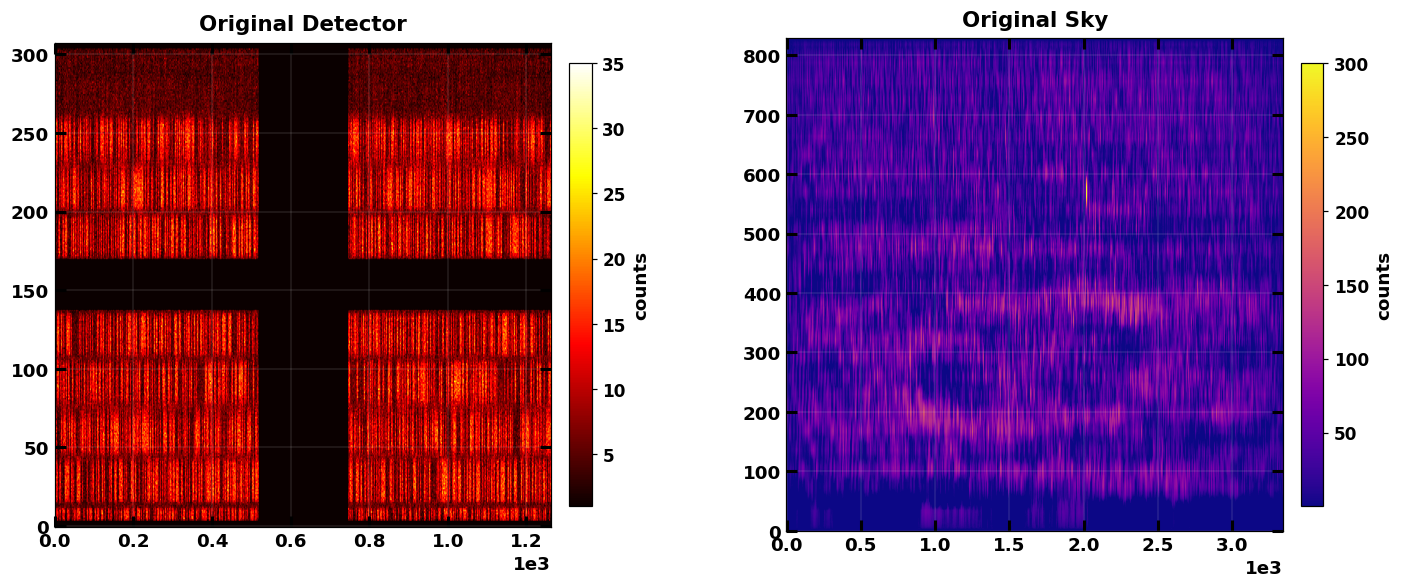

In [13]:
detector = count(wfm, sdlA.DLdata)[0]


EXP = 0.5
sky_vmax = 3e2

ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector,
            title='Original Detector',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(true_sky_camA, EXP),
            title='Original Sky',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

In [49]:
# get residual detector image
retrieved = retrieve_detector(
    candidates=candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
resdet = detector - retrieved
#resdet = np.clip(detector - retrieved, a_min=0.0, a_max=detector.sum())
res_sky = decode(wfm, resdet)

# perform smoothing on residual detector image
KERNEL_SIZE = {
    'y': 11,
    'x': 7,
}
res_smoothed = ds.bkg_smoothing(
    detector=resdet,
    camera=wfm,
    kernelsize_y=KERNEL_SIZE['y'],
    kernelsize_x=KERNEL_SIZE['x'],
)
res_smooth_sky = decode(wfm, res_smoothed)

# get smoothed detector image
smoothed = np.clip(detector - res_smoothed, a_min=0.0, a_max=None)
#smoothed = detector - res_smoothed
smoothed_sky = decode(wfm, smoothed)

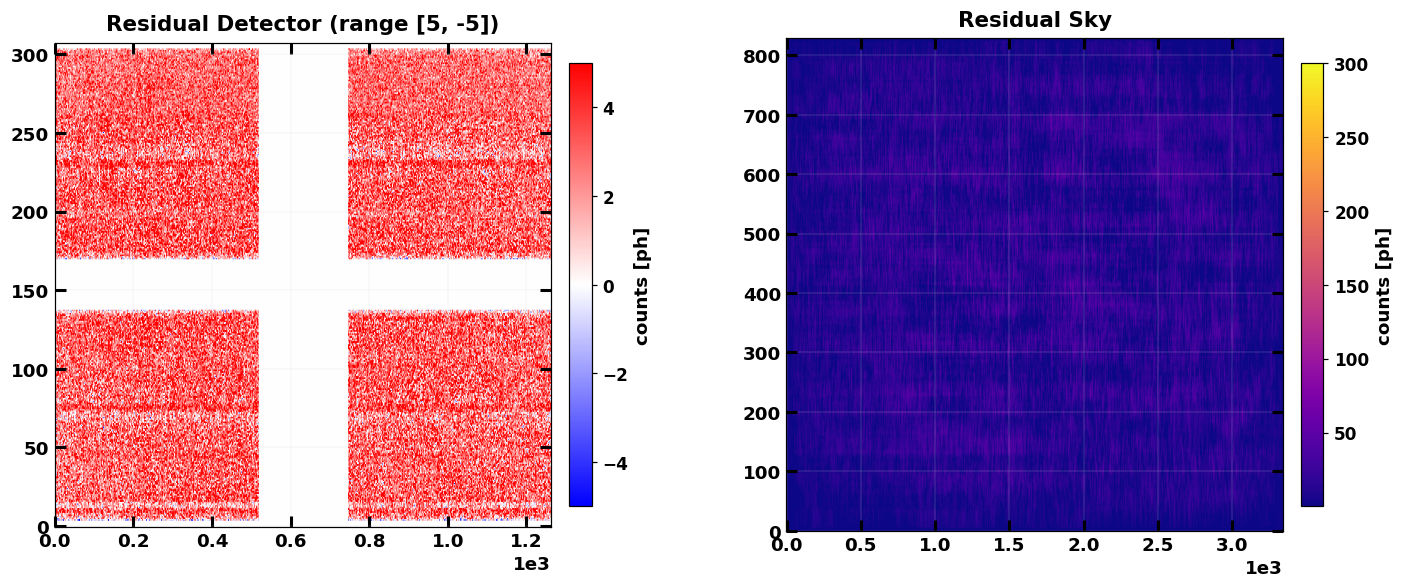

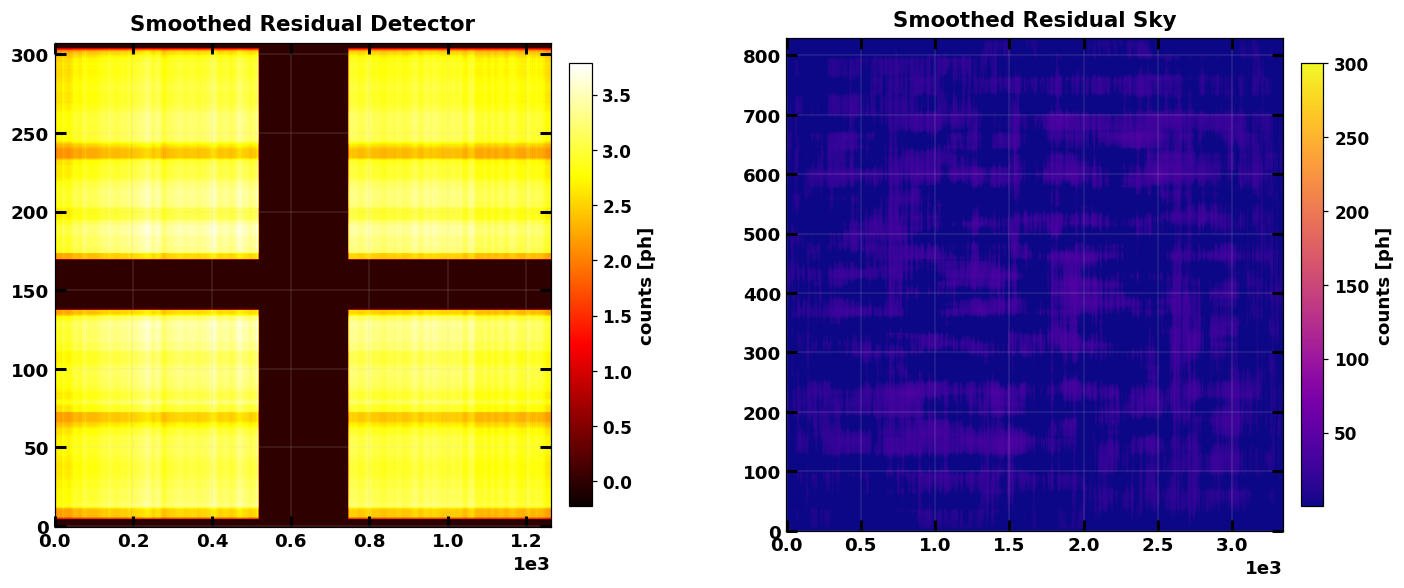

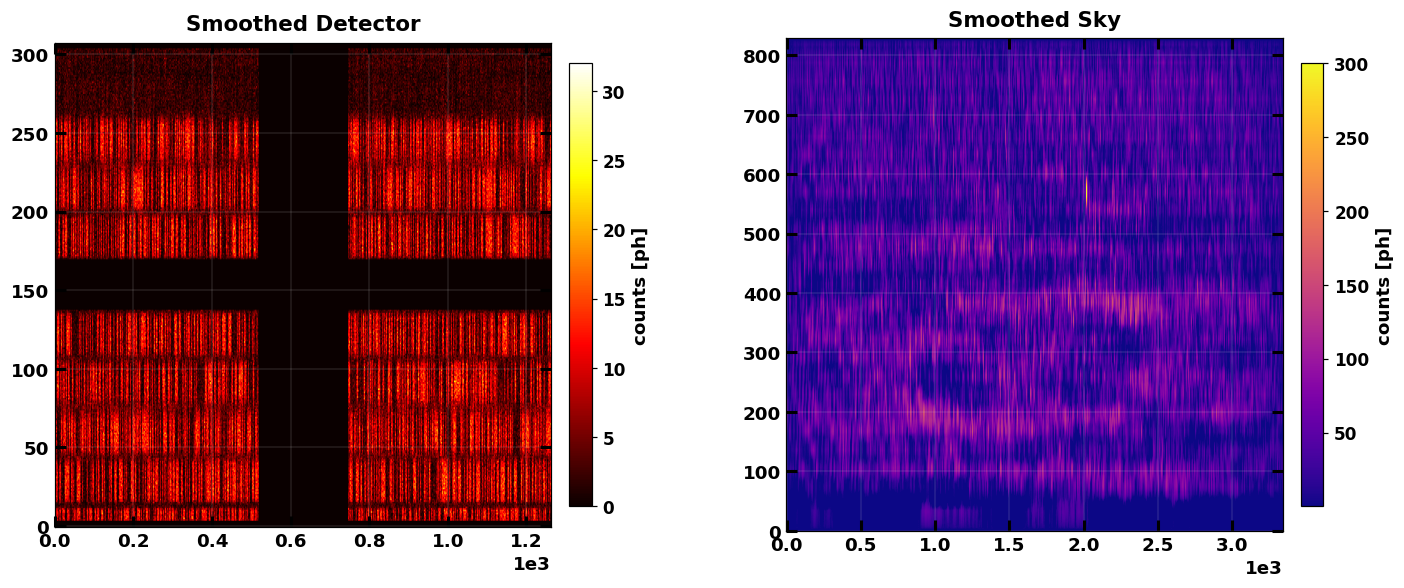

In [52]:
# plot residual detector and sky
LIM = 5
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=resdet,
            title='Residual Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'bwr',
                'vmax': LIM if LIM else None,
                'vmin': -LIM if LIM else None,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(res_sky, EXP),
            title='Residual Sky',
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

# plot smoothed residual detector and sky
LIM = 0
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=res_smoothed,
            title='Smoothed Residual Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'hot',
                'vmax': LIM if LIM else None,
                'vmin': -LIM if LIM else None,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(res_smooth_sky, EXP),
            title='Smoothed Residual Sky',
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

# plot smoothed original detector and sky
LIM = 0
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=smoothed,
            title='Smoothed Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'hot',
                'vmax': LIM if LIM else None,
                'vmin': -LIM if LIM else None,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(smoothed_sky, EXP),
            title='Smoothed Sky',
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

In [53]:
# profiles along X and Y axes
collapsed_det_x, collapsed_resdet_x, collapsed_res_smoothed_x, collapsed_smoothed_x = map(
    lambda x: np.sum(x, axis=0),
    (detector, resdet, res_smoothed, smoothed),
)

collapsed_det_y, collapsed_resdet_y, collapsed_res_smoothed_y, collapsed_smoothed_y = map(
    lambda x: np.sum(x, axis=1),
    (detector, resdet, res_smoothed, smoothed),
)

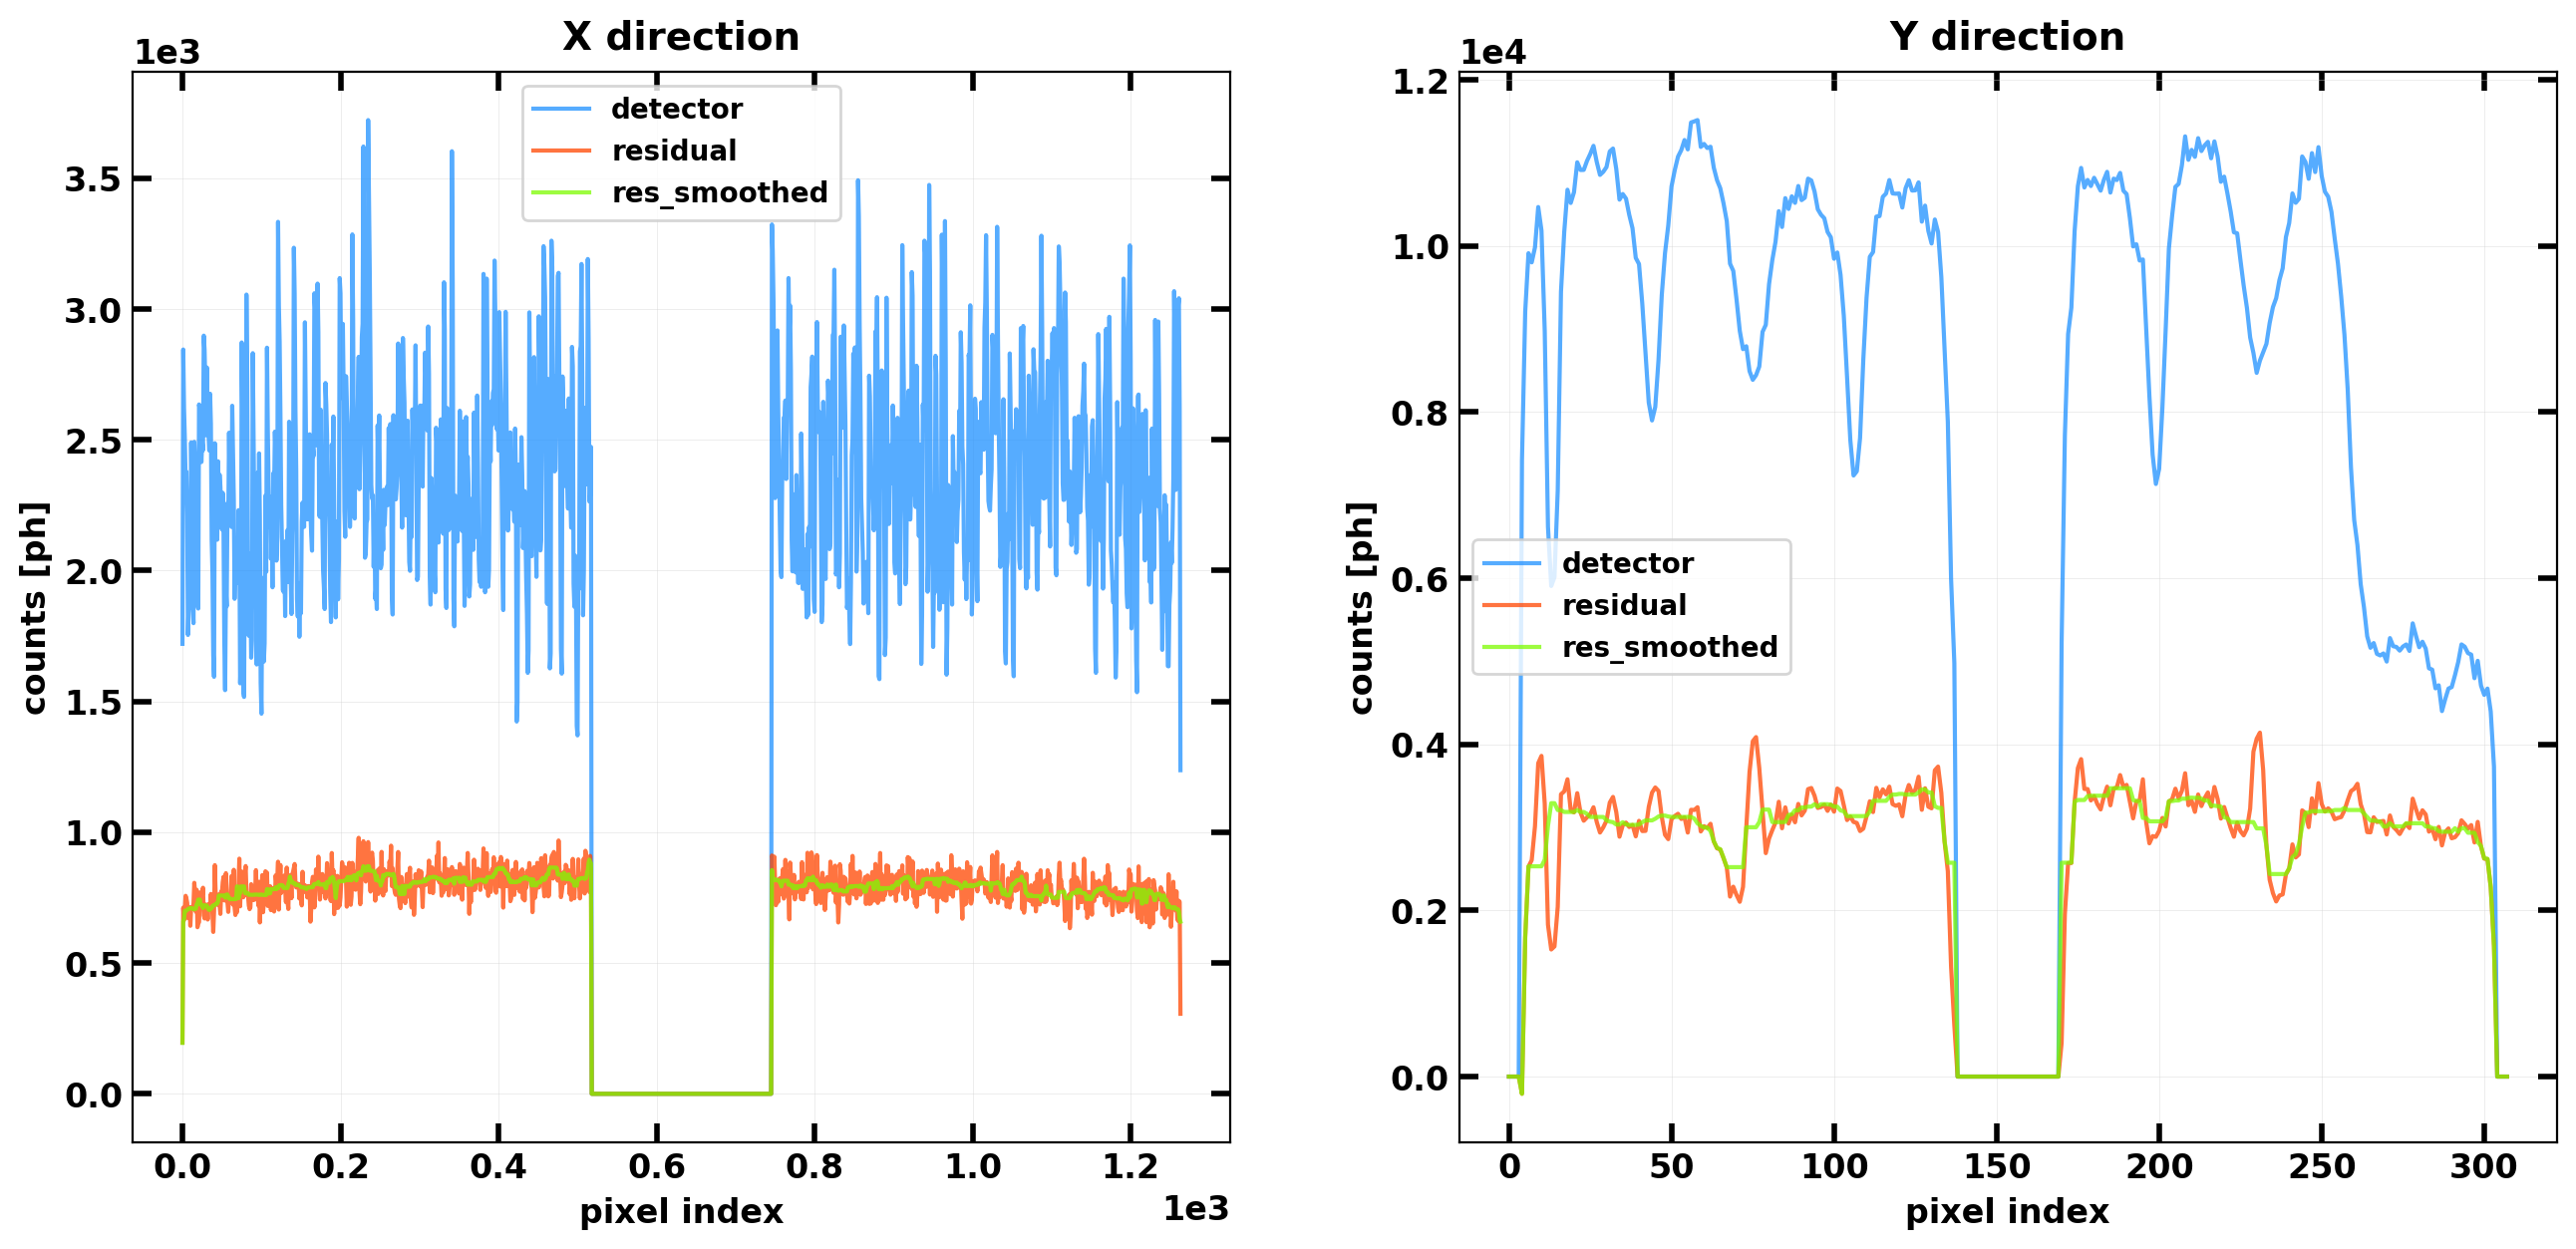

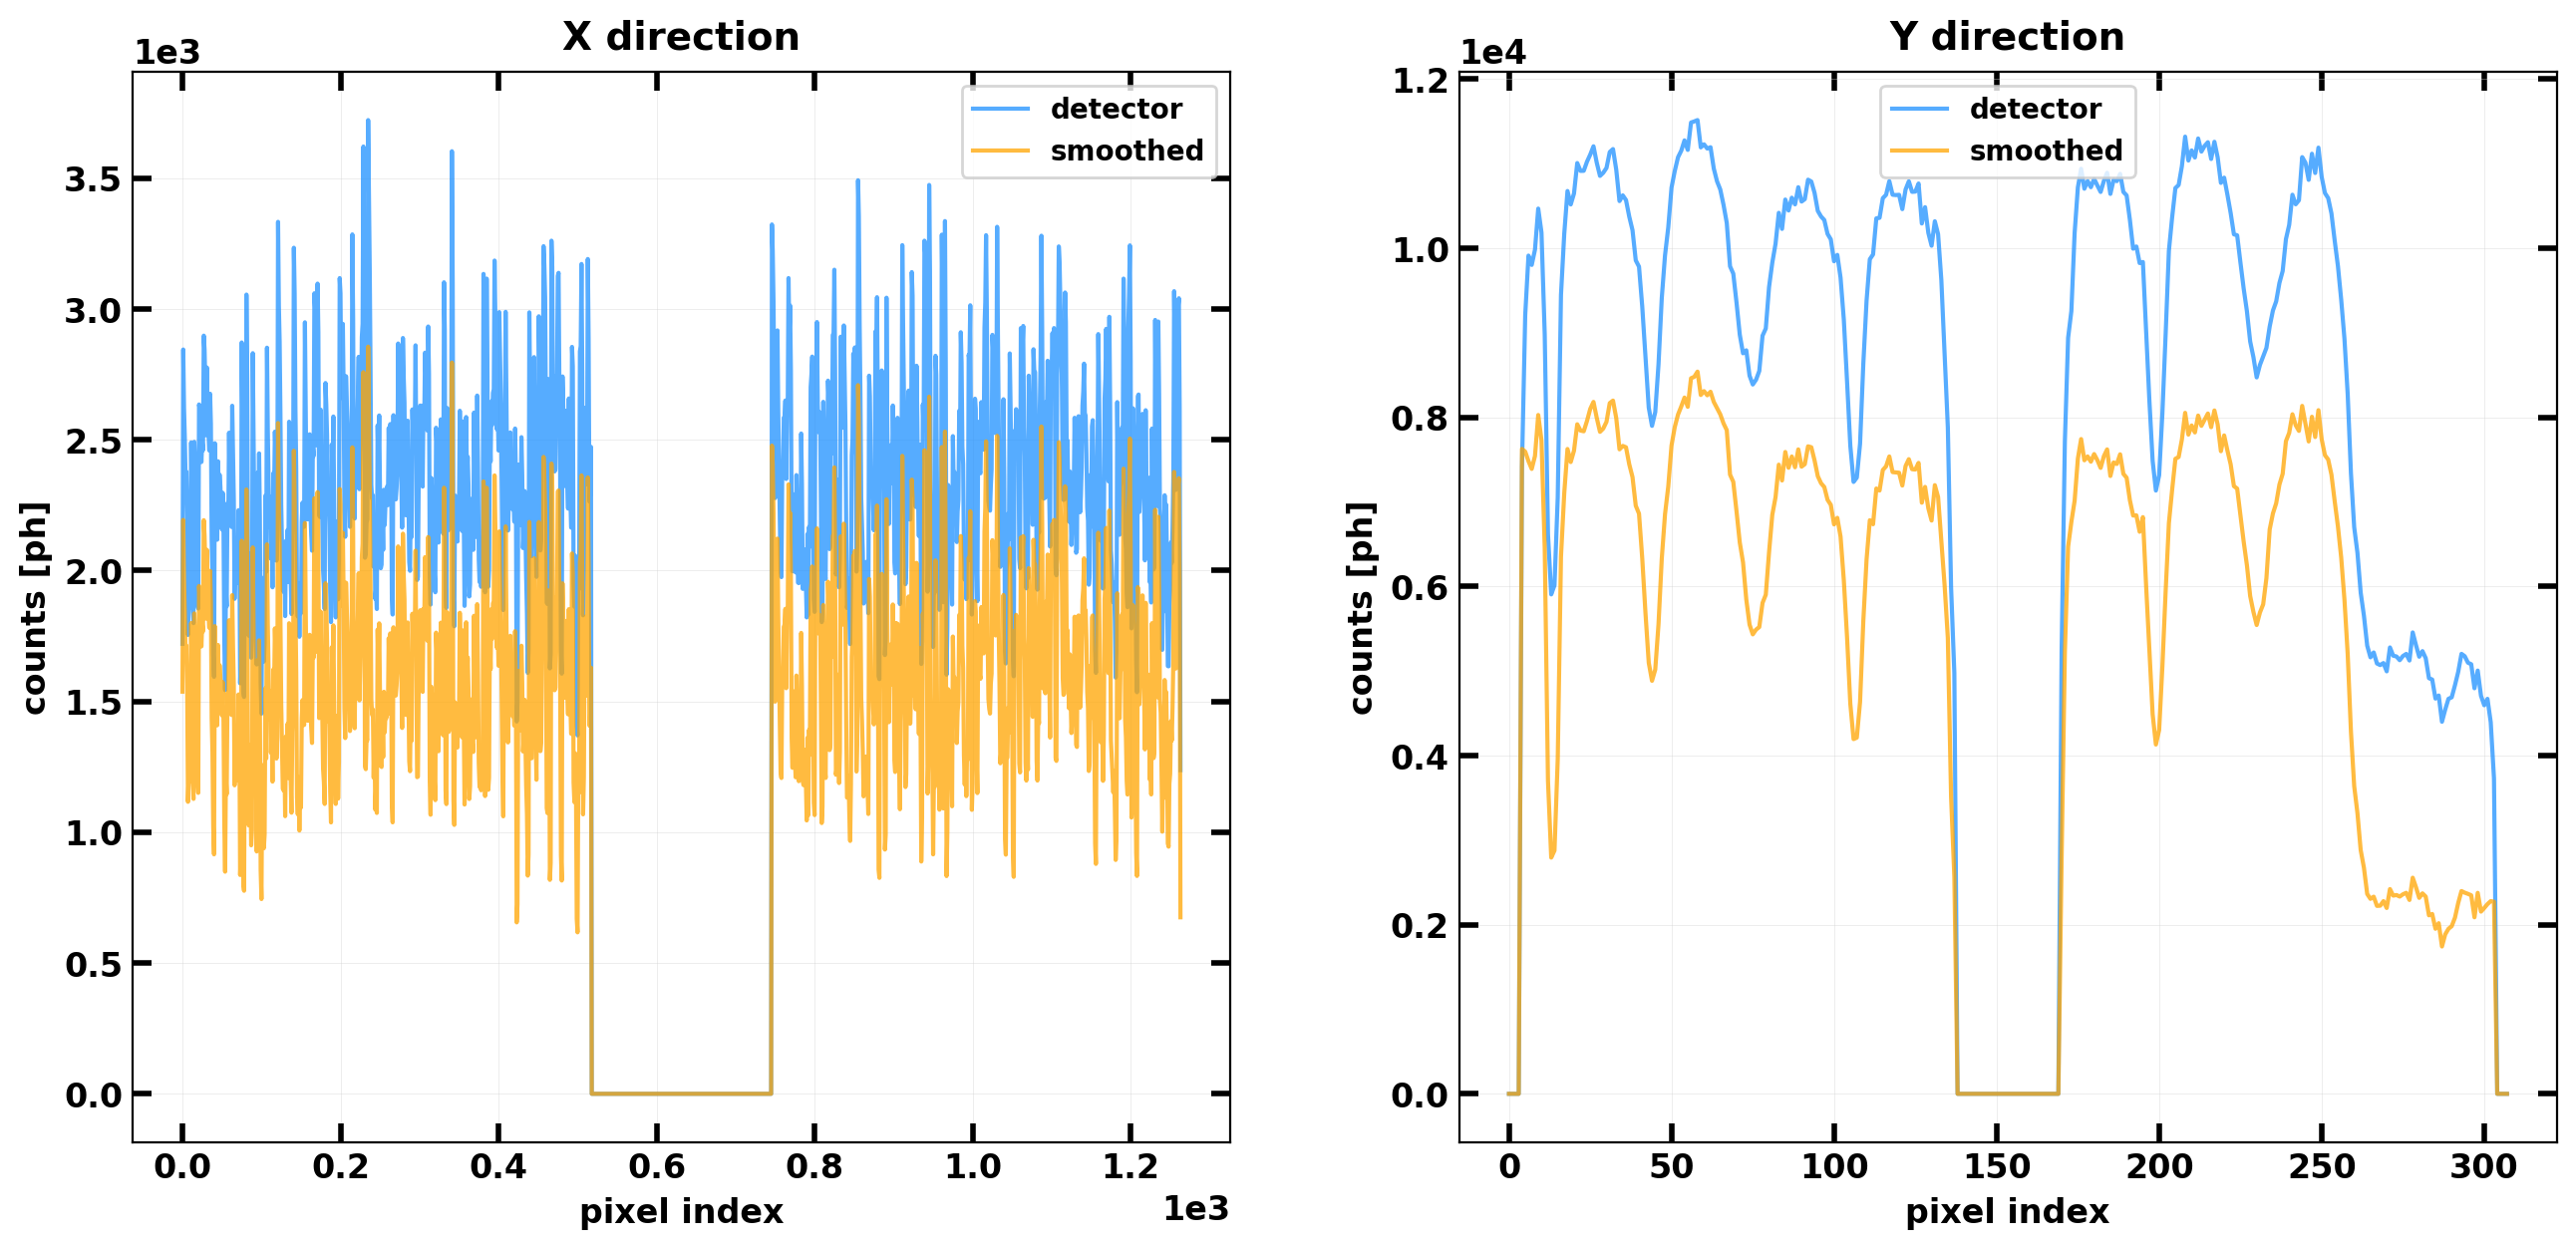

In [54]:
# plot detectors profiles
dmapx = ds.map4plot(
    arrs=(
        collapsed_det_x, collapsed_resdet_x,
        collapsed_res_smoothed_x,
    ),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'residual', 'res_smoothed'),
    color=('DodgerBlue', 'OrangeRed', 'LawnGreen'),
)
dmapy = ds.map4plot(
    arrs=(
        collapsed_det_y, collapsed_resdet_y,
        collapsed_res_smoothed_y,
    ),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'residual', 'res_smoothed'),
    color=('DodgerBlue', 'OrangeRed', 'LawnGreen'),
)
ds.plot(dmaps=(dmapx, dmapy), ncols=2)

dmapx_cfr = ds.map4plot(
    arrs=(
        collapsed_det_x, collapsed_smoothed_x,
    ),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'Orange'),
)
dmapy_cfr = ds.map4plot(
    arrs=(
        collapsed_det_y, collapsed_smoothed_y,
    ),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'Orange'),
)
ds.plot(dmaps=(dmapx_cfr, dmapy_cfr), ncols=2)

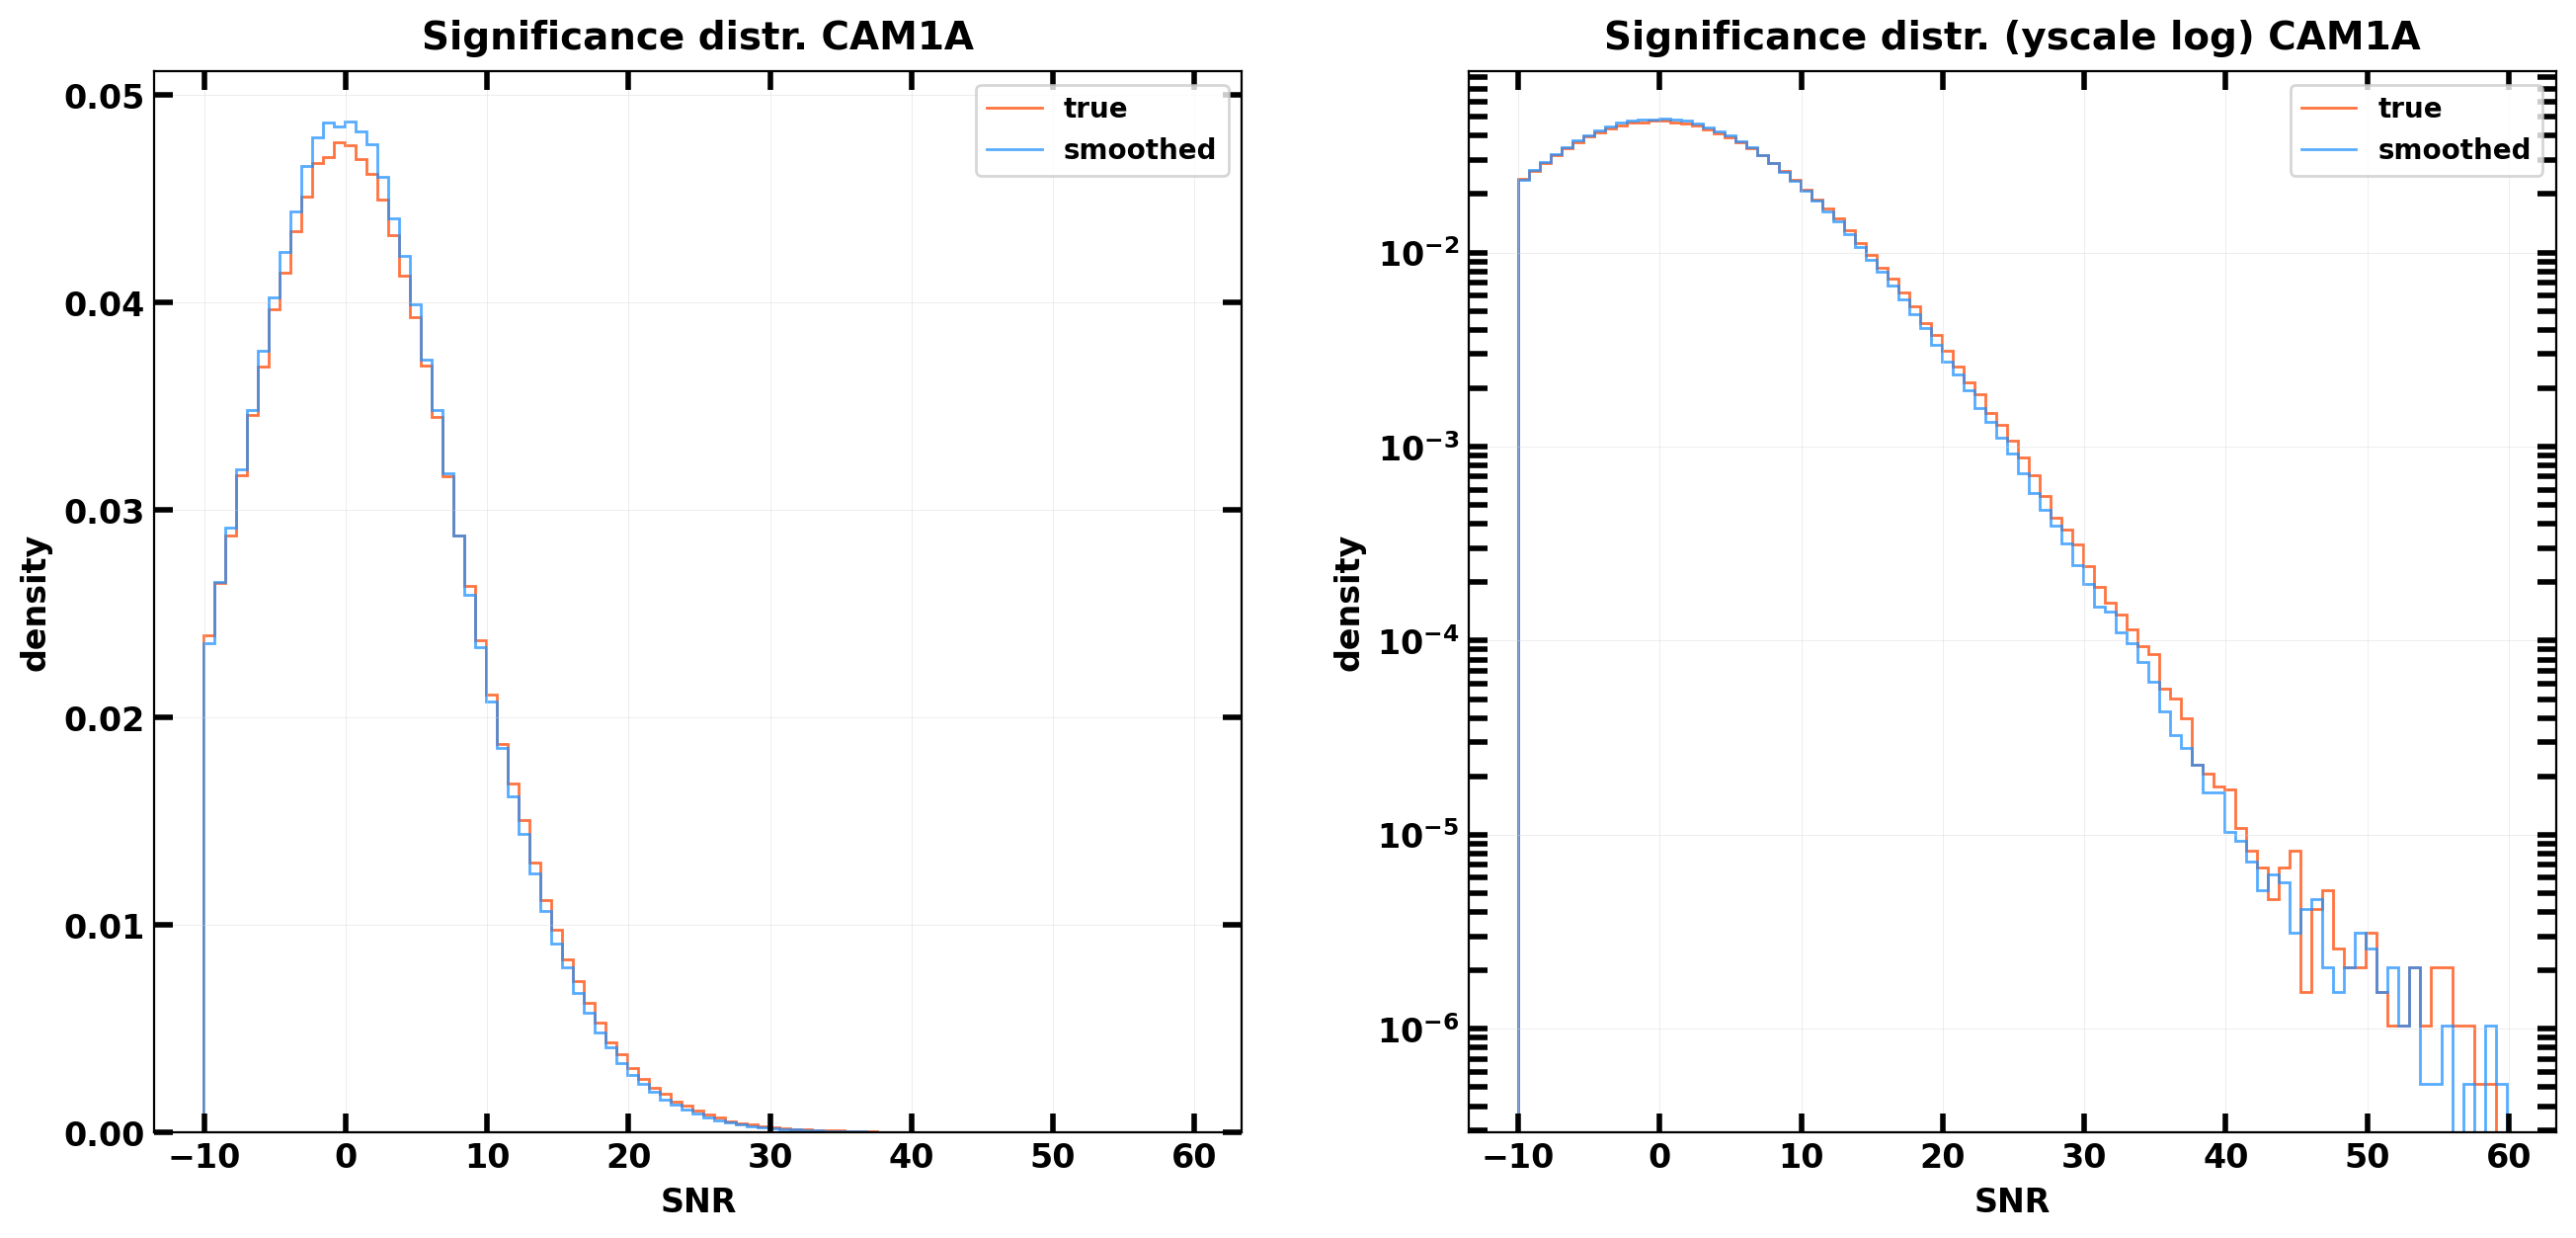

In [50]:
# sky significance distr. for true detector and smoothed detector
varmap = variance(wfm, detector)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camA = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
smoothed_skysnr_camA = ds.unframe(snratio(smoothed_sky, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camA, bins=num_bins, density=density)
hist_smoothed_skysnr, _ = np.histogram(smoothed_skysnr_camA, bins=bins, density=density)


x0, xN = -10, 60
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

In [44]:
smooth_analysis_ID = 'singleCAM_iros_upx2upy1_smoothing'
smooth_save_path = f'{save_path}../{smooth_analysis_ID}/'
log_camA_smoothed, _ = ds.load_database(smooth_save_path + f"IROS_sources_database_TEST_{smooth_analysis_ID}.fits")

# sources data + angular coords residues plot
data_DF(
    log=log_camA_smoothed,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)
smoothed_candidates = get_candidates(log_camA_smoothed, SMOOTHING_THRESHOLD)

# Loading data...
# Loading completed!
Source LEMX-CAM1AS1 not in catalogue...
Source LEMX-CAM1AS2 not in catalogue...
Pixel angular resolution at upscaling (x, y): 2, 1
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin

Number of candidates with SNR > 15.0: 12
Last: gx9+9 (snr = 16.24)
Following: x1735-444 (snr = 12.25)



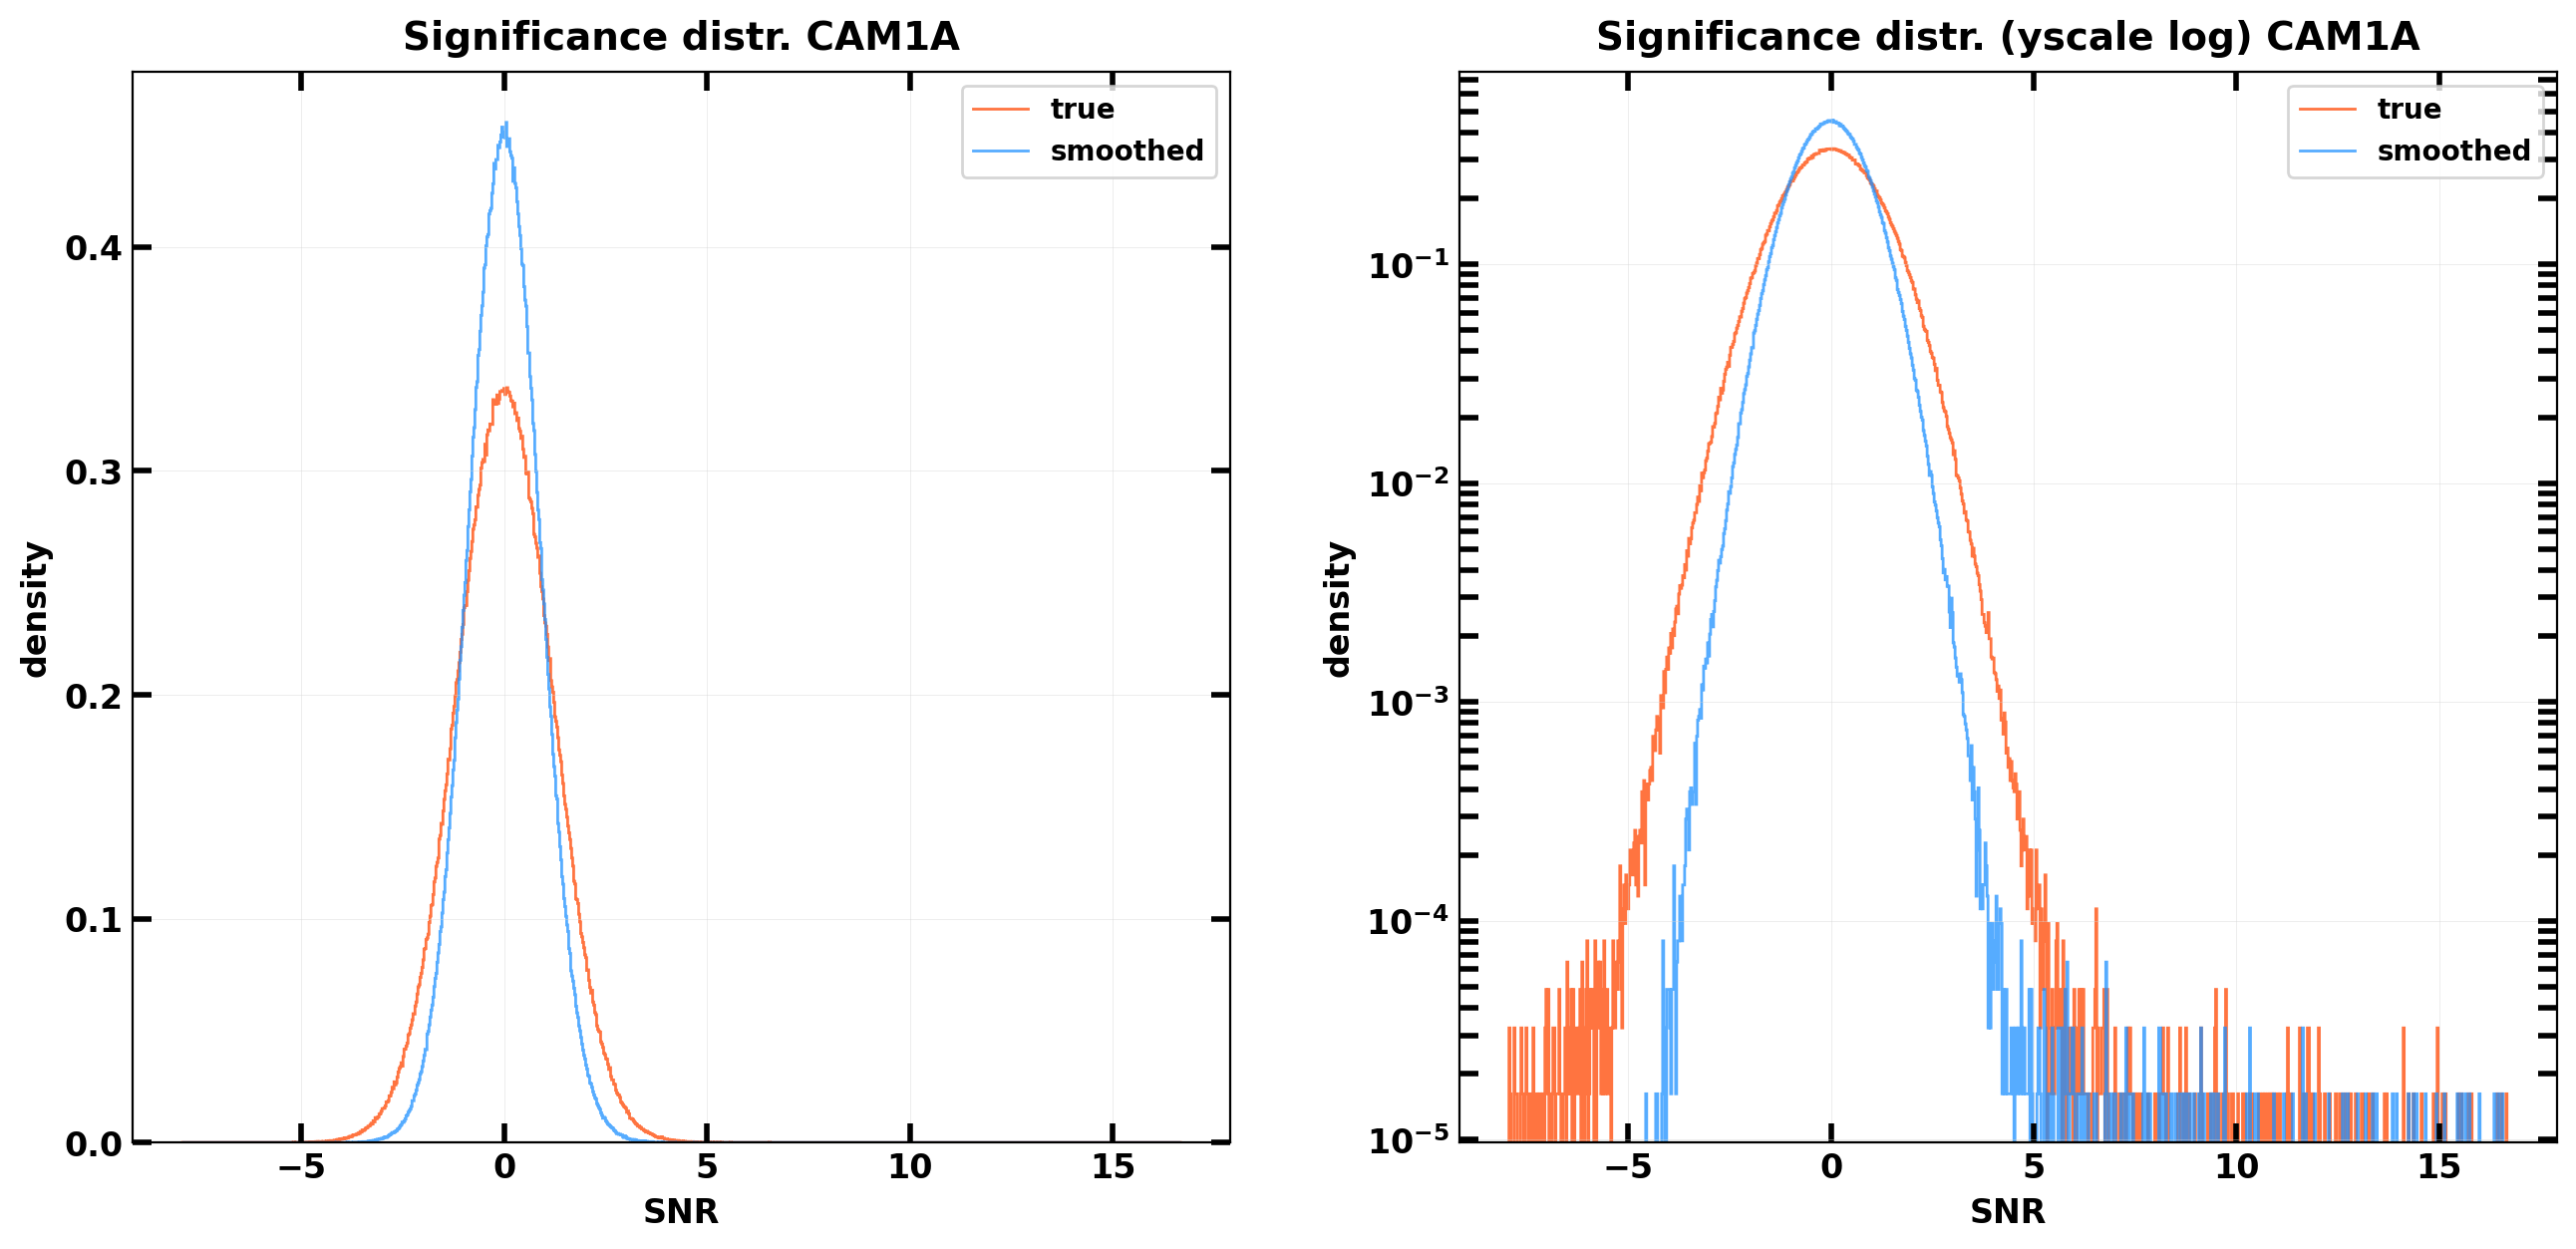

In [51]:
smoothed_retrieved = retrieve_detector(
    candidates=smoothed_candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_detector = np.clip(smoothed - smoothed_retrieved, a_min=0.0, a_max=None)
res_smoothed_sky = decode(wfm, res_detector)

res_skysnr_camA = ds.unframe(snratio(res_sky, varmap), ycut, xcut)
smoothed_skysnr_camA = ds.unframe(snratio(res_smoothed_sky, varmap), ycut, xcut)

hist_res_skysnr, bins = np.histogram(res_skysnr_camA, bins=num_bins, density=density)
hist_res_smoothed_skysnr, _ = np.histogram(smoothed_skysnr_camA, bins=bins, density=density)


x0, xN = None, None
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_res_skysnr[hist_slice], hist_res_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_res_skysnr[hist_slice], hist_res_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
# CFR IROS fluences with TRUE fluences from WISEMAN (wto and with smoothing) -- OCCHIO AL CLIP

from bloodmoon.types import CoordEquatorial
from astropy.io.fits.fitsrec import FITS_rec

def select_source_photons(
    coords: CoordEquatorial | tuple[CoordEquatorial, ...],
    data: FITS_rec,
    verbose: bool = True,
) -> FITS_rec:
    """
    Selects photon events relative to the input source RA/Dec coords.
    """
    mask = np.ones(len(data), dtype=bool)
    coords_ = (coords,) if isinstance(coords, CoordEquatorial) else coords
    for c in coords_:
        mask &= (
            (np.isclose(data['RA'], c.ra) & np.isclose(data['DEC'], c.dec))
        )
    selected = data[mask]
    if verbose:
        print(f'Selected {len(selected)} ph out of {len(data)} ph.')
    return selected


def extract_catalogue_fluences(
    log: Log,
    catalogue: CatalogueLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources fluences.
    """
    sources, fluences = [], []
    for sourceID in log.log['ID']:
        if sourceID in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)][0]    # NOTE!!!
            coords = CoordEquatorial(source['RA'], source['DEC'])
            print(f'# Source: {sourceID}')
            total_photons = select_source_photons(coords, catalogue.DLdata)
            det_image = count(camera, total_photons)[0]
            sources.append(sourceID)
            fluences.append(np.sum(det_image * (camera.bulk > 0)))
        else:
            print(f'Source {sourceID.upper()} not in catalogue...')
            sources.append(sourceID)
            fluences.append(np.nan)
        
    df = pd.DataFrame(
        {'ID': sources, 'fluence': fluences}
    )
    return df


def get_fluence_residues(
    log: Log,
    catalogue: CatalogueLoader,
    camera: CodedMaskCamera,
) -> NDArray:
    """
    Computes the fluence residues between the IROS
    sources and the catalogue sources in [counts].
    """
    df = extract_catalogue_fluences(log, catalogue, camera)
    fluences = np.array(df['fluence'])
    return np.array(log.log['fluence']) - fluences


df = extract_catalogue_fluences(log_camA, catalogueA, wfm)
fluences_res = get_fluence_residues(log_camA, catalogueA, wfm)
print(*zip(df['ID'], fluences_res))

**Analysis for LEM-X Camera B**

In [ ]:
assert ANALYSIS_CAM1B

AssertionError: 